In [ ]:
import numpy as np
import pandas as pd

In [ ]:
data = pd.read_csv("/content/diabetes.csv")

In [ ]:
data

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1
...,...,...,...,...,...,...,...,...,...
763,10,101,76,48,180,32.9,0.171,63,0
764,2,122,70,27,0,36.8,0.340,27,0
765,5,121,72,23,112,26.2,0.245,30,0
766,1,126,60,0,0,30.1,0.349,47,1


In [ ]:
data.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


In [ ]:
data.isnull().sum()

,0
Pregnancies,0
Glucose,0
BloodPressure,0
SkinThickness,0
Insulin,0
BMI,0
DiabetesPedigreeFunction,0
Age,0
Outcome,0


In [ ]:
data.corr()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
Pregnancies,1.000000,0.129459,0.141282,-0.081672,-0.073535,0.017683,-0.033523,0.544341,0.221898
Glucose,0.129459,1.000000,0.152590,0.057328,0.331357,0.221071,0.137337,0.263514,0.466581
BloodPressure,0.141282,0.152590,1.000000,0.207371,0.088933,0.281805,0.041265,0.239528,0.065068
SkinThickness,-0.081672,0.057328,0.207371,1.000000,0.436783,0.392573,0.183928,-0.113970,0.074752
Insulin,-0.073535,0.331357,0.088933,0.436783,1.000000,0.197859,0.185071,-0.042163,0.130548
BMI,0.017683,0.221071,0.281805,0.392573,0.197859,1.000000,0.140647,0.036242,0.292695
DiabetesPedigreeFunction,-0.033523,0.137337,0.041265,0.183928,0.185071,0.140647,1.000000,0.033561,0.173844
Age,0.544341,0.263514,0.239528,-0.113970,-0.042163,0.036242,0.033561,1.000000,0.238356
Outcome,0.221898,0.466581,0.065068,0.074752,0.130548,0.292695,0.173844,0.238356,1.000000


In [ ]:
data['Outcome'].value_counts()

,count
Outcome,
0,500
1,268


In [ ]:
X = data.drop('Outcome', axis=1)
y = data['Outcome']

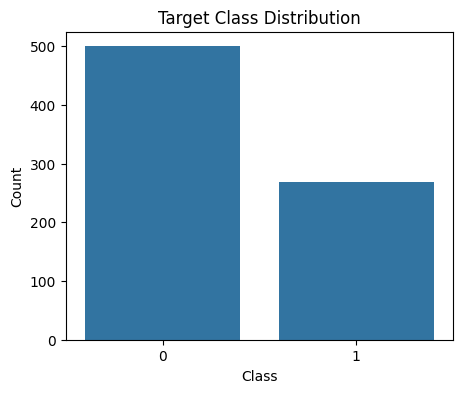

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(5,4))
sns.countplot(x=y)
plt.title("Target Class Distribution")
plt.xlabel("Class")
plt.ylabel("Count")
plt.show()


In [ ]:
X

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age
0,6,148,72,35,0,33.6,0.627,50
1,1,85,66,29,0,26.6,0.351,31
2,8,183,64,0,0,23.3,0.672,32
3,1,89,66,23,94,28.1,0.167,21
4,0,137,40,35,168,43.1,2.288,33
...,...,...,...,...,...,...,...,...
763,10,101,76,48,180,32.9,0.171,63
764,2,122,70,27,0,36.8,0.340,27
765,5,121,72,23,112,26.2,0.245,30
766,1,126,60,0,0,30.1,0.349,47


In [ ]:
y

,Outcome
0,1
1,0
2,1
3,0
4,1
...,...
763,0
764,0
765,0
766,1


In [ ]:
from sklearn.model_selection import train_test_split

In [ ]:

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)

print("Training samples:", X_train.shape)
print("Testing samples:", X_test.shape)


Training samples: (537, 8)
Testing samples: (231, 8)


In [ ]:
from sklearn.tree import DecisionTreeClassifier

In [ ]:
dt_model = DecisionTreeClassifier(
    criterion="gini",
    max_depth=6,
    random_state=42
)

In [ ]:
dt_model.fit(X_train, y_train)

DecisionTreeClassifier(max_depth=6, random_state=42)

In [ ]:
y_pred = dt_model.predict(X_test)

In [ ]:
from sklearn.metrics import accuracy_score
accuracy = accuracy_score(y_test, y_pred)
print("Decision Tree Accuracy:", accuracy)

Decision Tree Accuracy: 0.8008658008658008


In [ ]:
from sklearn.ensemble import RandomForestClassifier

In [ ]:
rf_model = RandomForestClassifier(
    n_estimators=100,
    max_depth=5,
    random_state=42
)

In [ ]:
rf_model.fit(X_train, y_train)

y_pred = rf_model.predict(X_test)

In [ ]:
accuracy = accuracy_score(y_test, y_pred)
print("Random Forest Accuracy:", accuracy)

Random Forest Accuracy: 0.7532467532467533


In [ ]:
from sklearn.svm import SVC

In [ ]:
svm = SVC(kernel='rbf', random_state=42)
svm.fit(X_train, y_train)

svm_pred = svm.predict(X_test)
svm_acc = accuracy_score(y_test, svm_pred)

print("SVM Accuracy:", svm_acc)


SVM Accuracy: 0.7445887445887446


# Newly Developed

Outcome
0    500
1    268
Name: count, dtype: int64


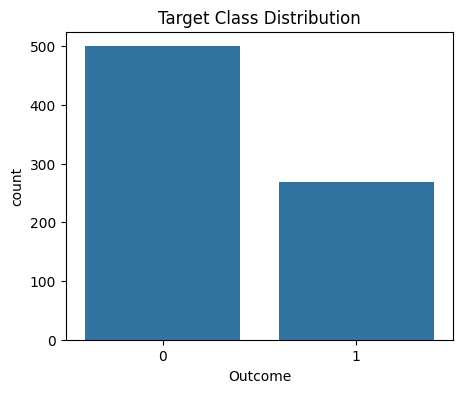

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# -----------------------------
# Load Data
# -----------------------------
data = pd.read_csv("/content/diabetes.csv")

# Check class distribution
print(data['Outcome'].value_counts())

plt.figure(figsize=(5,4))
sns.countplot(x=data['Outcome'])
plt.title("Target Class Distribution")
plt.show()

# -----------------------------
# Split Features & Target
# -----------------------------
X = data.drop('Outcome', axis=1)
y = data['Outcome']

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, stratify=y, random_state=42
)

# -----------------------------
# Evaluation Function
# -----------------------------
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score

def evaluate_model(name, y_test, y_pred, y_prob=None):
    print(f"\n===== {name} =====")
    print("Confusion Matrix:")
    print(confusion_matrix(y_test, y_pred))
    print("\nClassification Report:")
    print(classification_report(y_test, y_pred))

    if y_prob is not None:
        print("ROC-AUC:", roc_auc_score(y_test, y_prob))

In [ ]:
from sklearn.tree import DecisionTreeClassifier

dt = DecisionTreeClassifier(
    max_depth=6,
    class_weight='balanced',
    random_state=42
)

dt.fit(X_train, y_train)

dt_pred = dt.predict(X_test)
dt_prob = dt.predict_proba(X_test)[:,1]

evaluate_model("Decision Tree", y_test, dt_pred, dt_prob)


===== Decision Tree =====
Confusion Matrix:
[[114  36]
 [ 28  53]]

Classification Report:
              precision    recall  f1-score   support

           0       0.80      0.76      0.78       150
           1       0.60      0.65      0.62        81

    accuracy                           0.72       231
   macro avg       0.70      0.71      0.70       231
weighted avg       0.73      0.72      0.73       231

ROC-AUC: 0.7485185185185185


In [ ]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(
    n_estimators=100,
    max_depth=5,
    class_weight='balanced',
    random_state=42
)

rf.fit(X_train, y_train)

rf_pred = rf.predict(X_test)
rf_prob = rf.predict_proba(X_test)[:,1]

evaluate_model("Random Forest", y_test, rf_pred, rf_prob)


===== Random Forest =====
Confusion Matrix:
[[119  31]
 [ 24  57]]

Classification Report:
              precision    recall  f1-score   support

           0       0.83      0.79      0.81       150
           1       0.65      0.70      0.67        81

    accuracy                           0.76       231
   macro avg       0.74      0.75      0.74       231
weighted avg       0.77      0.76      0.76       231

ROC-AUC: 0.8445267489711934


In [ ]:
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

svm = SVC(
    kernel='rbf',
    class_weight='balanced',
    probability=True,
    random_state=42
)

svm.fit(X_train_scaled, y_train)

svm_pred = svm.predict(X_test_scaled)
svm_prob = svm.predict_proba(X_test_scaled)[:,1]

evaluate_model("SVM", y_test, svm_pred, svm_prob)


===== SVM =====
Confusion Matrix:
[[112  38]
 [ 22  59]]

Classification Report:
              precision    recall  f1-score   support

           0       0.84      0.75      0.79       150
           1       0.61      0.73      0.66        81

    accuracy                           0.74       231
   macro avg       0.72      0.74      0.73       231
weighted avg       0.76      0.74      0.74       231

ROC-AUC: 0.823909465020576


#Hyperparameter Tuning

In [ ]:
from sklearn.model_selection import GridSearchCV
from sklearn.tree import DecisionTreeClassifier

dt = DecisionTreeClassifier(class_weight='balanced', random_state=42)

param_grid_dt = {
    'max_depth': [3, 5, 7, None],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'criterion': ['gini', 'entropy']
}

grid_dt = GridSearchCV(
    dt,
    param_grid_dt,
    cv=5,
    scoring='roc_auc',
    n_jobs=-1
)

grid_dt.fit(X_train, y_train)

print("Best DT Params:", grid_dt.best_params_)

Best DT Params: {'criterion': 'gini', 'max_depth': 3, 'min_samples_leaf': 4, 'min_samples_split': 2}


In [ ]:
best_dt = grid_dt.best_estimator_
dt_pred = best_dt.predict(X_test)
dt_prob = best_dt.predict_proba(X_test)[:,1]

evaluate_model("Tuned Decision Tree", y_test, dt_pred, dt_prob)


===== Tuned Decision Tree =====
Confusion Matrix:
[[109  41]
 [ 17  64]]

Classification Report:
              precision    recall  f1-score   support

           0       0.87      0.73      0.79       150
           1       0.61      0.79      0.69        81

    accuracy                           0.75       231
   macro avg       0.74      0.76      0.74       231
weighted avg       0.78      0.75      0.75       231

ROC-AUC: 0.7952263374485596


In [ ]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(class_weight='balanced', random_state=42)

param_grid_rf = {
    'n_estimators': [100, 200],
    'max_depth': [None, 5, 10],
    'min_samples_split': [2, 5],
    'min_samples_leaf': [1, 2]
}

grid_rf = GridSearchCV(
    rf,
    param_grid_rf,
    cv=5,
    scoring='roc_auc',
    n_jobs=-1
)

grid_rf.fit(X_train, y_train)

print("Best RF Params:", grid_rf.best_params_)

Best RF Params: {'max_depth': 5, 'min_samples_leaf': 2, 'min_samples_split': 2, 'n_estimators': 200}


In [ ]:
from sklearn.metrics import confusion_matrix, classification_report, roc_auc_score

# Get best model
best_rf = grid_rf.best_estimator_

# Predictions
rf_pred = best_rf.predict(X_test)
rf_prob = best_rf.predict_proba(X_test)[:, 1]

print("===== Tuned Random Forest =====")

# Confusion Matrix
cm = confusion_matrix(y_test, rf_pred)
print("Confusion Matrix:")
print(cm)

# Classification Report
print("\nClassification Report:")
print(classification_report(y_test, rf_pred))

# ROC-AUC
auc = roc_auc_score(y_test, rf_prob)
print("ROC-AUC:", auc)

===== Tuned Random Forest =====
Confusion Matrix:
[[117  33]
 [ 26  55]]

Classification Report:
              precision    recall  f1-score   support

           0       0.82      0.78      0.80       150
           1       0.62      0.68      0.65        81

    accuracy                           0.74       231
   macro avg       0.72      0.73      0.72       231
weighted avg       0.75      0.74      0.75       231

ROC-AUC: 0.8409053497942386


In [ ]:
from sklearn.pipeline import Pipeline
from sklearn.svm import SVC
from sklearn.preprocessing import StandardScaler

pipe_svm = Pipeline([
    ('scaler', StandardScaler()),
    ('svm', SVC(class_weight='balanced', probability=True))
])

param_grid_svm = {
    'svm__C': [0.1, 1, 10],
    'svm__gamma': ['scale', 0.1, 0.01],
    'svm__kernel': ['rbf']
}

grid_svm = GridSearchCV(
    pipe_svm,
    param_grid_svm,
    cv=5,
    scoring='roc_auc',
    n_jobs=-1
)

grid_svm.fit(X_train, y_train)

print("Best SVM Params:", grid_svm.best_params_)

Best SVM Params: {'svm__C': 1, 'svm__gamma': 0.01, 'svm__kernel': 'rbf'}


In [ ]:
from sklearn.metrics import confusion_matrix, classification_report, roc_auc_score

# Get best tuned pipeline
best_svm = grid_svm.best_estimator_

# Predictions (NO manual scaling needed — pipeline handles it)
svm_pred = best_svm.predict(X_test)
svm_prob = best_svm.predict_proba(X_test)[:, 1]

print("===== Tuned SVM =====")

# Confusion Matrix
cm = confusion_matrix(y_test, svm_pred)
print("Confusion Matrix:")
print(cm)

# Classification Report
print("\nClassification Report:")
print(classification_report(y_test, svm_pred))

# ROC-AUC
auc = roc_auc_score(y_test, svm_prob)
print("ROC-AUC:", auc)

===== Tuned SVM =====
Confusion Matrix:
[[121  29]
 [ 24  57]]

Classification Report:
              precision    recall  f1-score   support

           0       0.83      0.81      0.82       150
           1       0.66      0.70      0.68        81

    accuracy                           0.77       231
   macro avg       0.75      0.76      0.75       231
weighted avg       0.77      0.77      0.77       231

ROC-AUC: 0.8355555555555555
